In [158]:
import matplotlib
matplotlib.use("Agg")

In [159]:
%matplotlib inline

# Overview

`sodetlib` supports two file formats for writing data:
- pysmurf `.dat` files with a format specified [here](https://github.com/slaclab/pysmurf/blob/main/README.DataFile.md).
- `.g3` files that use the G3 format.
In this tutorial we will show you how to take data, read data, and plot data in pysmurf, i.e. using `.dat` files
and without the specific `sodetlib` tools. Another tutorial will demonstrate how to write data out in `.g3` format.

Data generation requires a smurf system, however the data reading and plotting does not.

We will first generate the data, then show you how to install pysmurf on a local computer,
and use it in offline mode to read and analyze existing data.

# Generating Data

First we will create a new pysmurf instance using the det_config interface. Then we will be generating the following files: 
- **data file**: contains raw phase data for all enabled channels and TES biases
- **mask file**: Containes mapping from readout channel index to (band, channel)     
  combination
- **state file**: Contains full rogue state dump

In [160]:
from sodetlib.det_config import DetConfig

cfg = DetConfig()
cfg.load_config_files(slot=2)
S = cfg.get_smurf_control()

# Generates .dat and .mask file
print("Taking Data for 30 seconds")
data_file = S.take_stream_data(30, register_file=False)
mask_file = data_file.replace('.dat', '_mask.txt')

print("Saving state")
state_file = data_file.replace('.dat', '_state.yaml')
S.dump_state(output_file=state_file)

Taking Data for 30 seconds
[ 2020-12-02 01:58:10 ]  Starting to take data.
[ 2020-12-02 01:58:10 ]  Input downsample factor is None. Using value already in pyrogue: 20
[ 2020-12-02 01:58:10 ]  Flux ramp is AC-coupled.
[ 2020-12-02 01:58:10 ]  caput smurf_server_s2:AMCc:SmurfProcessor:Unwrapper:reset 1
[ 2020-12-02 01:58:10 ]  caput smurf_server_s2:AMCc:SmurfProcessor:Filter:reset 1
[ 2020-12-02 01:58:10 ]  Writing to file : /data/smurf_data/20201202/1606874290/outputs/1606874291.dat
[ 2020-12-02 01:58:14 ]  /data/smurf_data/20201202/1606874290/outputs/1606874291_mask.txt
[ 2020-12-02 01:58:14 ]  Writing frequency mask.
[ 2020-12-02 01:58:17 ]  caput smurf_server_s2:AMCc:SmurfProcessor:FileWriter:Open 1
[ 2020-12-02 01:58:47 ]  caput smurf_server_s2:AMCc:SmurfProcessor:FileWriter:Close 1
[ 2020-12-02 01:58:47 ]  caput smurf_server_s2:AMCc:FpgaTopLevel:AppTop:AppCore:enableStreaming 0
[ 2020-12-02 01:58:47 ]  Waiting 0.15 seconds after...
[ 2020-12-02 01:58:48 ]  Done waiting.
[ 2020-12-

In [161]:
import os

data_size = os.path.getsize(data_file)/1e6
print(f"Data file: {data_file} ({data_size:.0f} MB)")
print(f"Mask file: {mask_file}")
print(f"State file: {state_file}")

Data file: /data/smurf_data/20201202/1606874290/outputs/1606874291.dat (50 MB)
Mask file: /data/smurf_data/20201202/1606874290/outputs/1606874291_mask.txt
State file: /data/smurf_data/20201202/1606874290/outputs/1606874291_state.yaml


### The SMuRF Channel mask
The mask file contains a map from absolute smurf channel number to readout channel number. 

This is a text file with a single column, where the row number (indexed at 0) is the readout channel number and the value is the absolute-smurf-channel number. The absolute channel number is different from the channel number because it is unique for each band-channel combination. To convert between the two:
$$
\mathrm{abs\ smurf\ chan} = 512 \times \mathrm{band} + \mathrm{smurf\ chan}
$$
The following cell prints the first 10 absolute channel numbers in the readout stream along wiht their band/channel combinations.

In [162]:
with open(mask_file, 'r') as f:
    for _ in range(10):
        abs_chan = int(f.readline())
        print(f'{abs_chan} --> band {abs_chan // 512}, chan {abs_chan % 512}')

1027 --> band 2, chan 3
1031 --> band 2, chan 7
1035 --> band 2, chan 11
1039 --> band 2, chan 15
1043 --> band 2, chan 19
1047 --> band 2, chan 23
1051 --> band 2, chan 27
1059 --> band 2, chan 35
1062 --> band 2, chan 38
1063 --> band 2, chan 39


### Rogue state

The rogue state is stored as a yaml dictionary. Below we show how to read it in, and the root-level dictionary keys.

In [163]:
import yaml
with open(state_file) as f:
    rogue_state = yaml.safe_load(f)

In [164]:
from pprint import pprint
pprint(list(rogue_state.keys()))

['epics_root',
 'R_sh',
 'bias_line_resistance',
 'high_low_current_ratio',
 'high_current_mode_bool',
 'all_bias_groups',
 'fs',
 'default_data_dir',
 'tune_dir',
 'init',
 'bad_mask',
 'amplifier',
 'attenuator',
 'pic_to_bias_group',
 'bias_group_to_pair',
 'tune_band',
 'flux_ramp',
 'constant',
 'timing',
 'smurf_cmd_dir',
 'ultrascale_temperature_limit_degC',
 'status_dir',
 'outputs']


# Installing and using pysmurf on your own machine

`pysmurf` is a public github repo and can be downloaded here - <a href="https://github.com/slaclab/pysmurf">https://github.com/slaclab/pysmurf</a>.

It can be installed directly from the PyPI servers with

To install `pysmurf` from source, you can clone the repository and install with pip using the following commands:

Documentation is built using Sphinx, and follows the Google Style Docstrings. The latest compiled version is [available here](https://pysmurf.readthedocs.io/en/main/).

To build the documentation first install the pysmurf package, then run:

Output will be located in _build/html. You can view the compiled documentation by opening _build/html/index.html in the browser of your choice.

If you haven't imported it above, go ahead and import pysmurf & make sure it is in your PYTHONPATH

In [69]:
import pysmurf.client
print(pysmurf)

<module 'pysmurf' from '/usr/local/src/pysmurf/python/pysmurf/__init__.py'>


If you're not on a SMuRF server, you'll need to instatiate pysmurf with a flag telling it not to try and talk to the EPICs server (and other things). You'll also need to tell it where the cfg file the data was taken with is (as of right now - we need a better strategy for this). Here's stupid way to find the path to your pysmurf's config file directory:

In [107]:
S = pysmurf.client.SmurfControl(offline=True)

[ 2020-12-01 22:26:45 ]  Offline mode


# SMuRF example data in this tutorial

This tutorial has some SMuRF data in it for you to try loading on your own machine offline.  That data is in the smurf_tutorials/example_data directory (not in git).

## Tune data 

Load tune data.

In [165]:
# Loads full tunefile
S.load_tune(cfg.dev.exp['tunefile'])

[ 2020-12-02 02:01:32 ]  filename explicitly given. Overriding last_tune bool in load_tune.
[ 2020-12-02 02:01:32 ]  Done loading tuning
[ 2020-12-02 02:01:32 ]  Loading tune data for all bands=[0, 1, 2, 3].


Tune data is now loaded into pysmurf.  Keep in mind the tune data is just a numpy npy file, so you don't have to load it using pysmurf.  Let's look at what's in the tune files.  Loading the tune file populates a dictionary in pysmurf named freq_resp.  It's a nested dictionary.  The keys of freq_resp are the bands for which tune data exists in the file - in this case, that's bands 2 & 3, or 5-5.5GHz and 5.5-6GHz:

In [166]:
S.freq_resp.keys()

dict_keys([0, 1, 2, 3])

Each band dictionary has the following keys (descending into band 2, for example):

In [167]:
S.freq_resp[3].keys()

dict_keys(['lock_status', 'find_freq', 'tone_power', 'resonances'])

<code>lock_status</code> is a dictionary populated by the pysmurf <code>check_lock</code> routine, which checks if channels are tracking well.  It wasn't run for this dataset, so there's no information available on this here:

In [168]:
S.freq_resp[3]['lock_status']

{}

<code>tone_power</code> is the tone power (the amplitudeScale fw variable) at which the tune data was taken with.  In this case, 11:

In [169]:
S.freq_resp[3]['tone_power']

12

For the hardware this tune was taken with, 12 corresponds to about -26dBm per tone at the SMuRF RF output, and approximately -70dBm per tone into the resonators.  Those power levels are close to optimal for most existing uMUX resonator chips.  Each unit of amplitudeScale corresponds to an increment or decrement of 3dB.  

<code>find_freq</code> is populated by the pysmurf <code>find_freq</code> routine, which slowly sweeps a tone over the entire band frequency range, using it to measure the complex transmission as a function of frequency.  It contains the following keys:

In [170]:
S.freq_resp[3]['find_freq'].keys()

dict_keys(['subband', 'f', 'resp', 'timestamp', 'resonance'])

This tune file doesn't actually have the <code>find_freq</code> data - <code>f</code> and </resp> are all zeros.  But it does have a record of the resonance frequencies found from a previous <code>find_freq</code> dataset that must have been loaded for this tune : 

In [171]:
import numpy as np
np.set_printoptions(threshold=10)
resonance=S.freq_resp[3]['find_freq']['resonance']
print(resonance)

[-245.20000974 -243.88000969 -241.88000961 ... -104.20000414 -103.1600041
 -100.84000401]


These are in MHz, and w.r.t. the band center.  Since this is band 3, that means the resonator frequency found at the first element, -241.1 MHz, was at 5.509 GHz (=5.75GHz - 241.1 MHz).

Last, the <code>resonances</code> in the <code>find_freq</code> dictionary contains the results from the pysmurf <code>setup_notches</code> algorithm - the results of a fine scan of transmission vs frequency for each resonator candidate found by the <code>find_freq</code> routine, and the tracking algorithm inputs computed from that data.  We sometimes colloquially call these results "etaScans."  This is the critical information that pysmurf needs to hand off to the fw to configure each readout channel for tracking.  The keys of the <code>resonances</code> dictionary are the resonator indices.  Let's look at the first.

In [172]:
S.freq_resp[3]['resonances'][0]

{'freq': 5504.7839902566275, 'eta': (0.27272283472927045+1.583838632461146j), 'eta_scaled': 0.3348223482743449, 'eta_phase': 80.22998733024743, 'r2': 1, 'eta_mag': 1.6071473355791503, 'latency': 0, 'Q': 1, 'freq_eta_scan': array([5504.49999026, 5504.50199026, 5504.50399026, ..., 5505.09599026,
       5505.09799026, 5505.09999026]), 'resp_eta_scan': array([-0.06721795+0.00754178j, -0.06722546+0.00763738j,
       -0.0672574 +0.00767207j, ..., -0.07770526-0.0085156j ,
       -0.07770145-0.00829971j, -0.07772923-0.00815272j]), 'subband': 12, 'channel': 281, 'offset': -0.41600001589449676}

Here's a quick summary of each of these variables:<br>

<code>freq</code>: the refined resonator frequency determined from the eta scan.<br>
<code>eta</code>: the computed eta.<br>
<code>eta_scaled</code>: the computed scaled eta (proportional to abs(eta), needed by fw).<br>
<code>eta_phase</code>: the complex eta phase.<br>
<code>r2</code>: not currently useful, always 1.<br>
<code>eta_mag</code>: the magnitude of eta.<br>
<code>latency</code>: not currently useful, always 0.<br>
<code>Q</code>: not currently useful, always 1.<br>
<code>freq_eta_scan</code>: the frequencies scanned in the etaScan, in MHz.<br>
<code>resp_eta_scan</code>: the complex response measured at each frequency, units arbitrary.<br>
<code>subband</code>: the subband this resonator was scanned in.<br>
<code>channel</code>: the channel assigned to this resonator for readout.<br>
<code>offset</code>: the offset of freq from the center of this resonators' subband.<br>

From this data, you can plot the complex transmission close in on every resonator that was assigned to a readout channel by this tune.  For instance, for the first channel in this dataset:

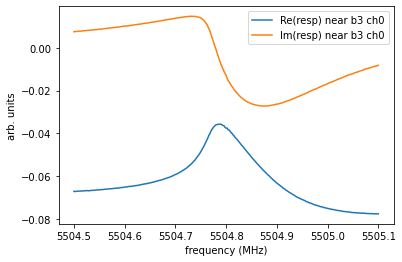

In [175]:
import matplotlib.pylab as plt
import numpy as np
%matplotlib inline

band=3
chIdx=0
etaScan=S.freq_resp[band]['resonances'][chIdx]
freq_eta_scan=etaScan['freq_eta_scan']
resp_eta_scan=etaScan['resp_eta_scan']

plt.plot(freq_eta_scan,np.real(resp_eta_scan),label=f'Re(resp) near b{band} ch{chIdx}')
plt.plot(freq_eta_scan,np.imag(resp_eta_scan),label=f'Im(resp) near b{band} ch{chIdx}')
plt.ylabel('arb. units')
plt.xlabel('frequency (MHz)')
plt.legend()
plt.show()

In total, this tune file contains etaScans over

In [177]:
nChannels=0
bands=[2,3]
for band in bands:
    nChannelsInThisBand=len(S.freq_resp[band]['resonances'].keys())
    print('Channels etaScanned in band %d = %d'%(band,nChannelsInThisBand))
    nChannels+=nChannelsInThisBand
print('-------------')
print('Channels etaScanned in bands %s = %d'%(str(bands),nChannels))

Channels etaScanned in band 2 = 62
Channels etaScanned in band 3 = 52
-------------
Channels etaScanned in bands [2, 3] = 114


But this is before any quality cuts.  The <code>find_freq</code> algorithm that finds resonator candidates for the etaScans is purposely over-permissive.  Of these 454, 410 or so of them end up tracking well.  If you look through the etaScan results for all of these channels, you'll likely be able to spot all or nearly all of the channels that either 1) aren't real resonators but fooled the <code>find_freq</code> routine or 2) don't track well despite being actual resonators.

### Loading and plotting timestream data

Now we will load the data we have just taken. `read_stream_data` returns the following:
- **times**: A 1d array of timestamps for the data
- **phases**: An array of size (channels, samples) containing phase data in radians.
- **mask**: An array of size (n_band, 512) containing the map from (band, channel) to readout channel index.

In [181]:
times, phases, mask = S.read_stream_data(data_file)

[ 2020-12-02 02:06:06 ]  Reading /data/smurf_data/20201202/1606874290/outputs/1606874291.dat
Processing data records from /data/smurf_data/20201202/1606874290/outputs/1606874291.dat
[ 2020-12-02 02:06:06 ]  2048 elements loaded
[ 2020-12-02 02:06:06 ]  4096 elements loaded
Processed 6005 data records from /data/smurf_data/20201202/1606874290/outputs/1606874291.dat
Processed a total of 6005 data records


The mask is shape (n_band, n_channel) and is -1 for all unassigned channels and is the array index for the assigned channels. So if mask[2,15] = 4, then band 2 channel 15 is the 4th element (0 indexed) in the datafile.

In [182]:
np.shape(mask)

(4, 512)

Below we print the non-zero mask elements. Note that they match the order of the mask_file printed above.

In [183]:
bands, chans = np.where(mask != -1)
print(bands)
print(channel)

[2 2 2 ... 3 3 3]
[  3   7  11 ... 395 435 451]


Let us arbitrarily choose a channel and plot it.

In [184]:
idx = 10  # Readout channel index
print('SMuRF Channel: Band {} Ch {:03}'.format(bands[idx], chans[idx]))
print(f'Readout channel: {mask[bands[idx],chans[idx]]}')

SMuRF Channel: Band 2 Ch 043
Readout channel: 10


t[0]=9440935743664801


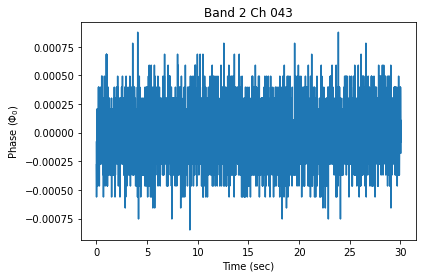

In [185]:
import matplotlib.pyplot as plt
dat_ch=phases[idx]
t_sec=(times-times[0])/1.e9
print('t[0]=%d'%(t[0]))
plt.plot(t_sec,dat_ch-np.mean(dat_ch))
plt.title('Band {} Ch {:03}'.format(bands[idx], chans[idx]))
plt.ylabel('Phase ($\Phi_{0}$)')
plt.xlabel('Time (sec)')
plt.show()

The timestamp is in ns since Jan 1, 1970 (<a href="https://en.wikipedia.org/wiki/Unix_time">because it's awesome</a>) and the y axis is in units of the SQUID flux quantum.  To convert the units to equivalent TES current, just multiply by 

The conversion from phi0 to pA is set in the pysmurf config file and is not changed during operation. Unfortunately it is not loaded to the offline pysmurf module so we have to set it manually. You can check you're pysmurf config file to see what the correct conversion factor is. In our case it's 9e6

In [186]:
pA_per_phi0 = 9e6

In [187]:
print('%f pA/Radian'%(S.pA_per_phi0/(2.*np.pi)))

1432394.487827 pA/Radian


where pA_per_phi0 is in the config file that was loaded when pysmurf was instantiated.  pA_per_phi0 is a function of the coupling (mutual inductance) of the inductor inline with the TES to the SQUID.

This data was taken at ~180 Hz (set by the MCE syncbox rate).  Here's

/usr/local/lib/python3.6/dist-packages/scipy/signal/spectral.py:1963: UserWarning: nperseg = 8192 is greater than input length  = 6005, using nperseg = 6005
  .format(nperseg, input_length))


[ 2020-12-02 02:07:37 ]  Unable to fit noise model. Reporting mean noise: 28.83 pA/rtHz
white noise level = 28.8 pA/rt.Hz


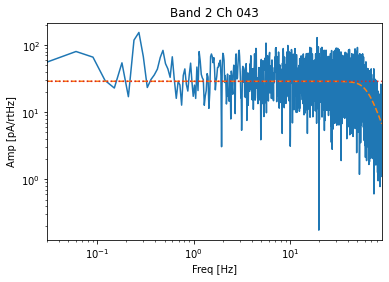

In [188]:
from scipy import signal
pA_ch= phases[idx] * pA_per_phi0 / (2.*np.pi)
f, Pxx = signal.welch(pA_ch, nperseg=2**13, fs=180, detrend='constant')
Axx = np.sqrt(Pxx)  # pA
plt.plot(f,Axx)

plt.title('Band {} Ch {:03}'.format(bands[idx], chans[idx]))
plt.gca().set_xlabel('Freq [Hz]')
plt.gca().set_xlim(f[1],f[-1])
plt.gca().set_ylabel('Amp [pA/rtHz]')
plt.gca().set_yscale('log')
plt.gca().set_xscale('log')

popt,pcov,f_fit,Pxx_fit = S.analyze_psd(f,Axx)
wl,n,f_knee = popt

plt.plot(f_fit,Pxx_fit,linestyle = '--',label=r'$n=%.2f$' % (n))
plt.plot(f_knee,2.*wl,linestyle = 'none',marker = 'o',label=r'$f_\mathrm{knee} = %.2f\,\mathrm{Hz}$' % (f_knee))
plt.plot(f_fit,wl + np.zeros(len(f_fit)),linestyle = ':',label=r'$\mathrm{wl} = %.0f\,\mathrm{pA}/\sqrt{\mathrm{Hz}}$' % (wl))
print('white noise level = %0.1f pA/rt.Hz'%(wl))

This channel doesn't have any TES on it - this is just SQUID+resonator noise (and dominated by resonator TLS noise).  The large spike on the right is 60Hz.

## Tracking setup data

In [ ]:
f, df, sync = S.decode_data('example_data\\1549243856\\outputs\\1549244377.dat')
npts=300
idx=2
plt.plot(f[:,idx][:npts]-np.mean(f[:,idx][:npts]))
plt.plot(df[:,idx][:npts]-np.mean(df[:,idx][:npts]))

## IV data 

In [ ]:
fn_iv_raw_data='example_data\\1549243856\\outputs\\1549244462_iv_raw_data.npy'
S.analyze_slow_iv_from_file(fn_iv_raw_data, make_plot=True,
            show_plot=True, save_plot=False)